# Classification Part-A — K-Nearest Neighbors

This notebook implements one of the five required Classification Part-A algorithms using the Adult Income dataset.

## Problem Statement

Predict whether a person's annual income is **greater than $50K** from demographic, education, employment, and financial attributes.

# Classification Part-A — Dataset Audit and EDA

In [1]:

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "Review-1" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from classification_preprocessing import load_adult_dataset, prepare_features_target, build_preprocessor, save_result

RANDOM_STATE = 42

df = load_adult_dataset()

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())


Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


None

## Dataset Audit

In [2]:

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df["income"].value_counts(dropna=False).to_frame("count"))


Missing values:


,missing
occupation,2809
workclass,2799
native-country,857
age,0
fnlwgt,0
education,0
education-num,0
marital-status,0
relationship,0
race,0



Duplicate rows: 52

Data types:


,dtype
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object



Target distribution:


,count
income,
<=50K,37155
>50K,11687


## EDA — Target Distribution

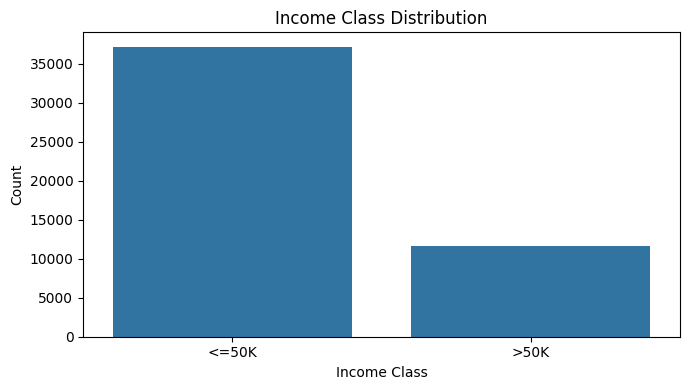

In [3]:

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="income")
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## EDA — Numerical Features

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


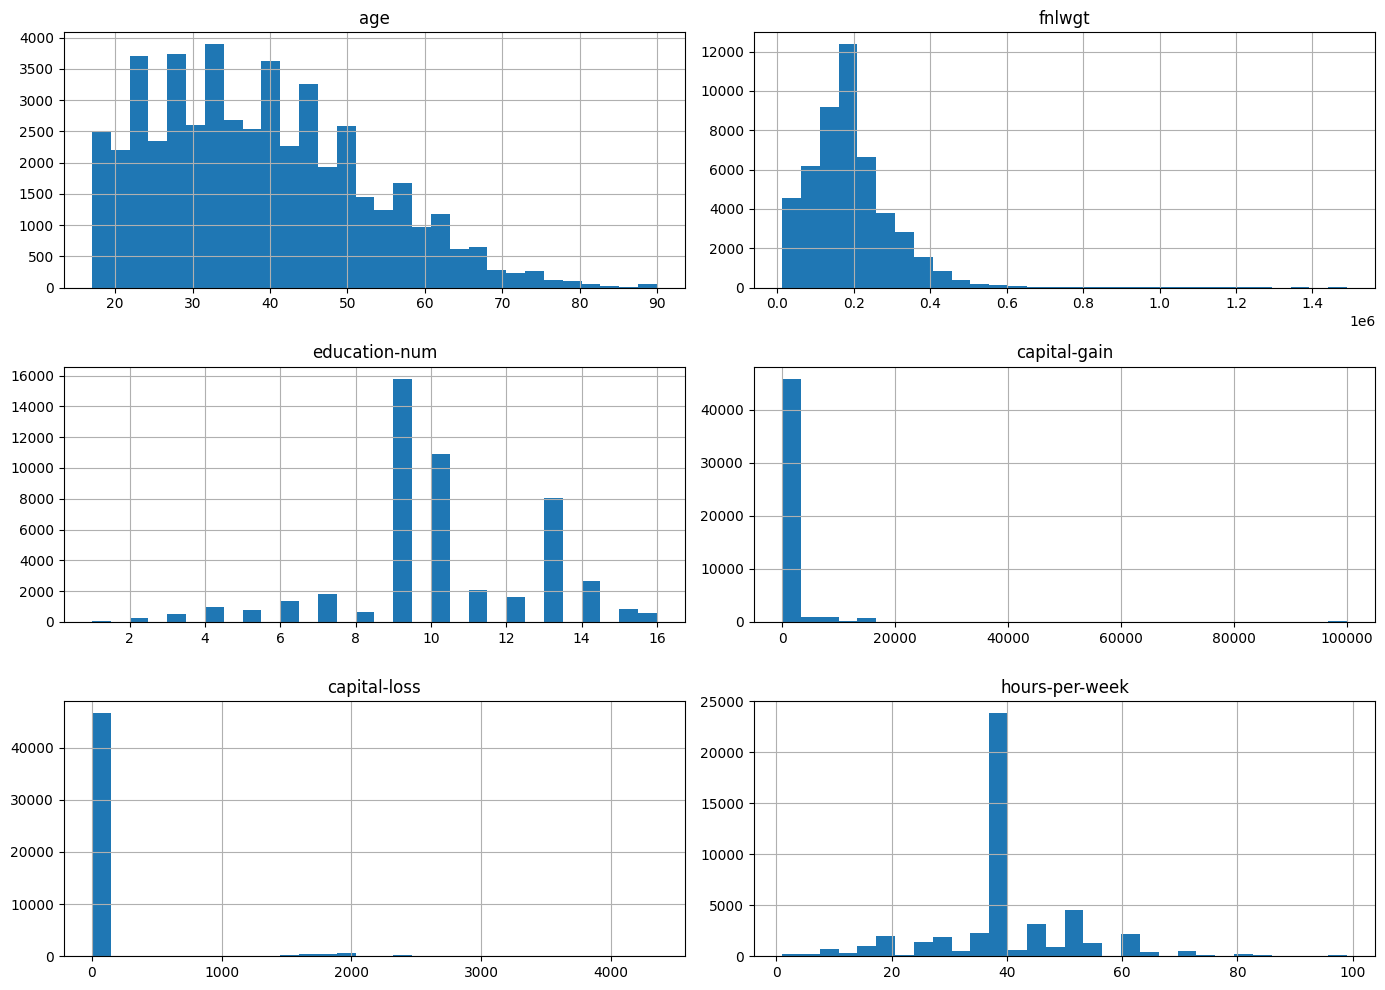

In [4]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


## EDA — Correlation Heatmap

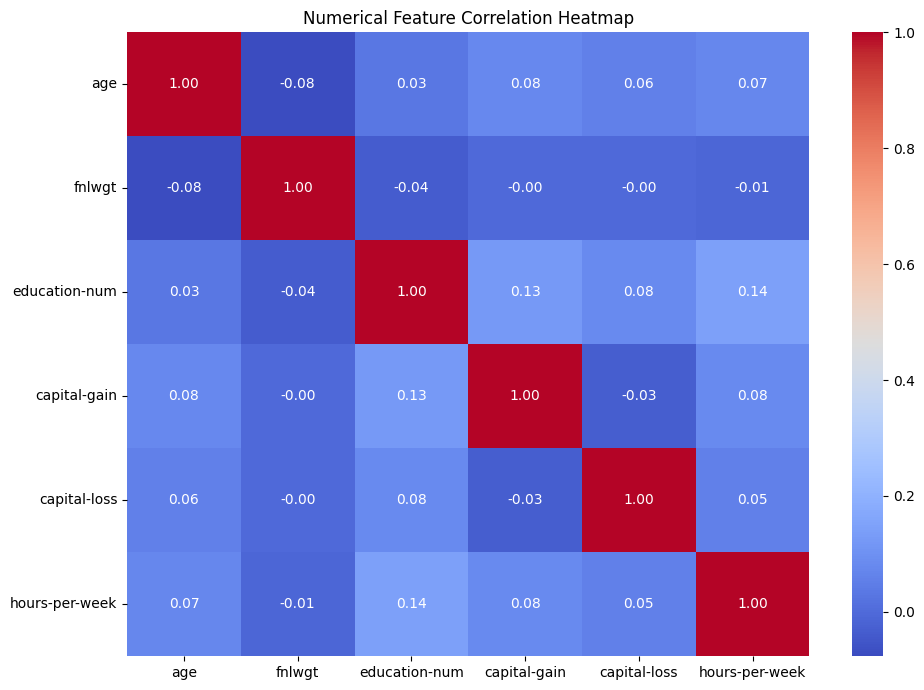

In [5]:

plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## Prepare Data

In [6]:

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "Review-1" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from classification_preprocessing import load_adult_dataset, prepare_features_target, build_preprocessor, save_result

RANDOM_STATE = 42

df = load_adult_dataset()
X, y = prepare_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)
print("Positive class rate in training:", y_train.mean())
print("Positive class rate in testing :", y_test.mean())

preprocessor = build_preprocessor(X_train)


Training shape: (39073, 14)
Testing shape : (9769, 14)
Positive class rate in training: 0.23927008420136667
Positive class rate in testing : 0.23932848807452145


## Build and Train Model

In [7]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5, weights="uniform", n_jobs=-1)

In [8]:

from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy       : {accuracy:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")


Accuracy       : 0.8268
Weighted F1    : 0.8228


## Confusion Matrix

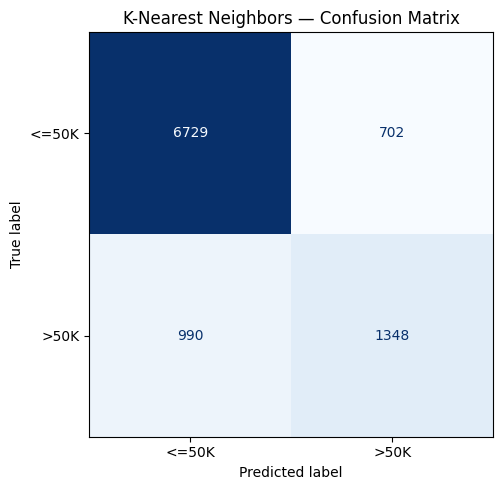

In [9]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title(f"K-Nearest Neighbors — Confusion Matrix")
plt.tight_layout()
plt.show()


## Result

In [10]:

result = {
    "model": "K-Nearest Neighbors",
    "accuracy": accuracy,
    "weighted_f1": weighted_f1,
}

output_path = save_result(result, "02_knn_classifier.csv")
print("Saved:", output_path)
pd.DataFrame([result])


Saved: /Users/venkataramana/Documents/SEMESTERS/5TH SEMESTER/MACHINE LEARNING/ML_Capstone/Review-1/results/02_knn_classifier.csv


,model,accuracy,weighted_f1
0,K-Nearest Neighbors,0.826799,0.822761
